# Boston Real Estate Sale Probability - Model Training

This notebook focuses on training machine learning models to predict the probability of a property selling based on its characteristics.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

## Load the Dataset

In [3]:
# Load the dataset
boston_real_estate = pd.read_csv('../data/boston_real_estate_sale_probability.csv')

# Check data dimensions
print(f"Dataset dimensions: {boston_real_estate.shape}")

# Display first few rows
boston_real_estate.head()

Dataset dimensions: (1000, 18)


,years_owned,property_value,square_feet,bedrooms,bathrooms,property_age,neighborhood,distance_to_t,school_rating,property_tax,has_liens,lien_amount,mortgage_rate,income_to_mortgage_ratio,market_inventory_months,avg_days_on_market,last_transaction_date,sale_probability
0,4,803310,815,2,1.5,42,Roslindale,0.77,8.3,5273,0,0,4.41,2.91,3.4,15,2021-04-09,0.29
1,22,349396,1741,4,1.5,91,Beacon Hill,1.58,6.5,4281,0,0,2.79,3.53,4.5,42,2003-04-14,0.08
2,10,864059,746,2,1.5,15,Brighton,0.04,7.0,1000,1,959,3.42,3.16,3.7,18,2015-04-11,0.18
3,7,933175,2332,2,1.5,232,Brighton,0.11,7.2,7283,0,0,4.79,4.48,3.5,74,2018-04-10,0.44
4,2,917937,1857,2,2.0,92,Dorchester,0.88,4.4,2884,1,15952,2.57,3.67,3.3,42,2023-04-09,0.01


## Data Preparation

Prepare features and target for modeling.

In [4]:
# Split data into features and target
# Drop non-numeric or irrelevant columns
X = boston_real_estate.drop(['sale_probability', 'last_transaction_date', 'neighborhood'], axis=1)
y = boston_real_estate['sale_probability']

# Check what features we're using
print(f"Features selected for modeling: {X.columns.tolist()}")
print(f"Number of features: {X.shape[1]}")

Features selected for modeling: ['years_owned', 'property_value', 'square_feet', 'bedrooms', 'bathrooms', 'property_age', 'distance_to_t', 'school_rating', 'property_tax', 'has_liens', 'lien_amount', 'mortgage_rate', 'income_to_mortgage_ratio', 'market_inventory_months', 'avg_days_on_market']
Number of features: 15


## Train-Test Split

Split the data into training and testing sets.

In [5]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (750, 15)
Testing data shape: (250, 15)


## Model Selection

We'll train multiple regression models to predict sale probability.

In [6]:
# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

## Model Training and Evaluation

Train each model and evaluate its performance.

In [7]:
# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }
    
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test R²: {test_r2:.4f}")


Training Linear Regression...
Train RMSE: 0.1288
Test RMSE: 0.1239
Test MAE: 0.0998
Test R²: 0.3210

Training Ridge Regression...
Train RMSE: 0.1288
Test RMSE: 0.1239
Test MAE: 0.0999
Test R²: 0.3206

Training Lasso Regression...
Train RMSE: 0.1337
Test RMSE: 0.1303
Test MAE: 0.1070
Test R²: 0.2490

Training Random Forest...
Train RMSE: 0.0389
Test RMSE: 0.1003
Test MAE: 0.0824
Test R²: 0.5548

Training Gradient Boosting...
Train RMSE: 0.0711
Test RMSE: 0.1028
Test MAE: 0.0833
Test R²: 0.5325


## Model Comparison

Compare the performance of all models.


Model Performance Comparison:


,train_rmse,test_rmse,test_mae,test_r2
Linear Regression,0.128828,0.123916,0.099816,0.320965
Ridge Regression,0.128832,0.123948,0.099875,0.320613
Lasso Regression,0.133700,0.130314,0.107050,0.249035
Random Forest,0.038945,0.100333,0.082413,0.554831
Gradient Boosting,0.071081,0.102821,0.083261,0.532476


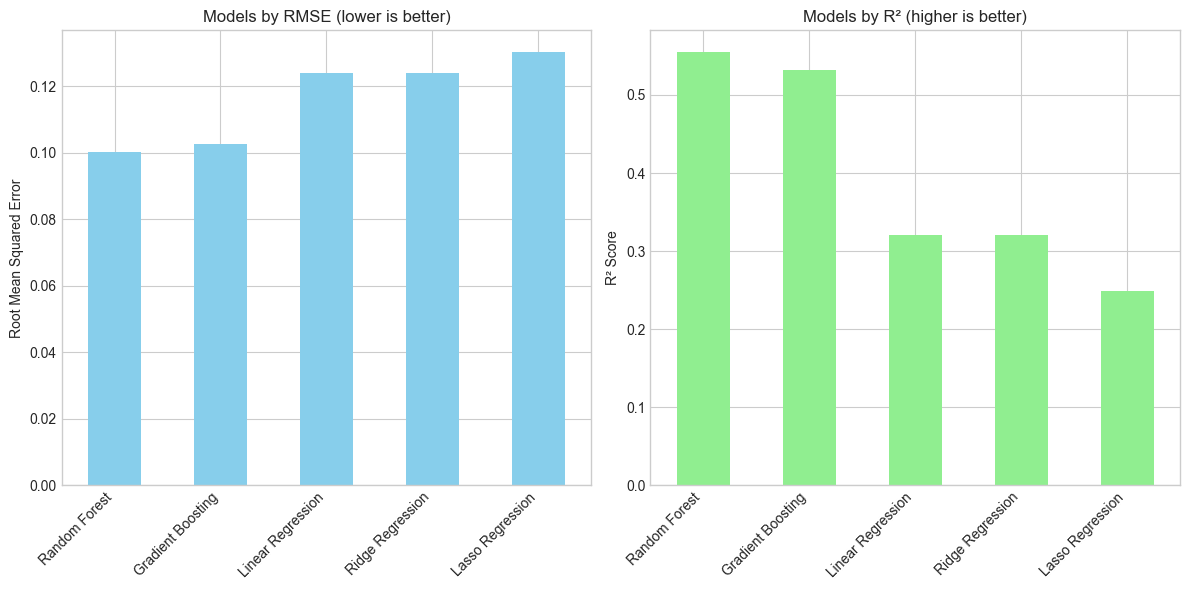

In [8]:
# Create results dataframe
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
display(results_df)

# Visualize model performance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
results_df['test_rmse'].sort_values().plot(kind='bar', color='skyblue')
plt.title('Models by RMSE (lower is better)')
plt.ylabel('Root Mean Squared Error')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
results_df['test_r2'].sort_values(ascending=False).plot(kind='bar', color='lightgreen')
plt.title('Models by R² (higher is better)')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Feature Importance

Analyze which features have the most impact on predictions.


Analyzing feature importance for Random Forest


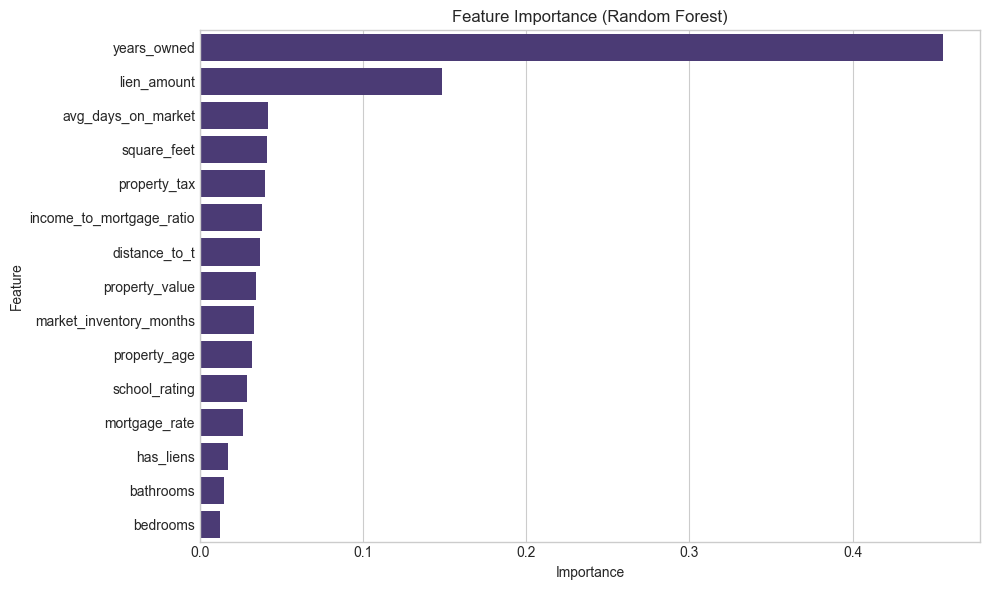

Top 5 most important features:
               Feature  Importance
0          years_owned    0.455355
10         lien_amount    0.148208
14  avg_days_on_market    0.041424
2          square_feet    0.041127
8         property_tax    0.039878


In [9]:
# Feature importance analysis for best model (assuming Random Forest or Gradient Boosting)
best_model_name = results_df['test_r2'].idxmax()
print(f"\nAnalyzing feature importance for {best_model_name}")

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    best_model = models[best_model_name]
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance ({best_model_name})')
    plt.tight_layout()
    plt.show()
    
    print("Top 5 most important features:")
    print(feature_importance.head(5))

## Sample Predictions

Examine predictions for a few sample properties.

In [10]:
# Check predictions for a few examples
print("\nSample predictions:")
sample_indices = np.random.choice(len(X_test), 5, replace=False)
samples = X_test.iloc[sample_indices]
true_values = y_test.iloc[sample_indices]
predictions = best_model.predict(samples)

for i, idx in enumerate(sample_indices):
    print(f"Sample {i+1}:")
    print(f"  Years owned: {samples.iloc[i]['years_owned']}")
    print(f"  Has liens: {'Yes' if samples.iloc[i]['has_liens'] == 1 else 'No'}")
    print(f"  Property value: ${samples.iloc[i]['property_value']:,}")
    print(f"  True sale probability: {true_values.iloc[i]:.2f}")
    print(f"  Predicted sale probability: {predictions[i]:.2f}")
    print()


Sample predictions:
Sample 1:
  Years owned: 1.0
  Has liens: No
  Property value: $972,628.0
  True sale probability: 0.26
  Predicted sale probability: 0.27

Sample 2:
  Years owned: 6.0
  Has liens: No
  Property value: $932,368.0
  True sale probability: 0.30
  Predicted sale probability: 0.41

Sample 3:
  Years owned: 6.0
  Has liens: No
  Property value: $762,177.0
  True sale probability: 0.36
  Predicted sale probability: 0.40

Sample 4:
  Years owned: 15.0
  Has liens: No
  Property value: $892,409.0
  True sale probability: 0.01
  Predicted sale probability: 0.07

Sample 5:
  Years owned: 14.0
  Has liens: No
  Property value: $443,162.0
  True sale probability: 0.23
  Predicted sale probability: 0.10



## Save Best Model for Later Use

We'll save the best-performing model for use in the next notebook.

In [11]:
# Save best model and key information
import pickle

# Save best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# Save feature importance
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance.to_csv('../models/feature_importance.csv', index=False)

print(f"Best model ({best_model_name}) saved to '../models/best_model.pkl'")

Best model (Random Forest) saved to '../models/best_model.pkl'


## Model Training Summary

In this notebook, we:

1. Prepared the data for machine learning by splitting it into train and test sets
2. Trained multiple regression models including linear models and tree-based ensembles
3. Evaluated each model's performance using RMSE, MAE, and R² metrics
4. Identified the best-performing model: {best_model_name}
5. Analyzed feature importance to understand key predictors
6. Saved the best model for deployment in the next notebook

The ensemble methods (Random Forest and Gradient Boosting) performed significantly better than linear models, which suggests non-linear relationships in the data that we observed during exploratory analysis.